# Project 1 — Naive Bayes
## Email Spam Detection

Classic Naive Bayes use case: classifying emails as spam/not-spam based on word-frequency-like features (synthetic counts of suspicious words, links, exclamation marks, sender reputation score).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)
np.random.seed(42)
pd.set_option('display.max_columns', None)


## 1. Generate / Load Data

In [2]:
n = 1000
is_spam = np.random.choice([0,1], n, p=[0.65,0.35])
num_links = np.where(is_spam==1, np.random.poisson(4, n), np.random.poisson(0.5, n))
num_exclaim = np.where(is_spam==1, np.random.poisson(5, n), np.random.poisson(0.8, n))
suspicious_words = np.where(is_spam==1, np.random.poisson(3, n), np.random.poisson(0.3, n))
sender_reputation = np.where(is_spam==1, np.random.normal(3, 1.5, n), np.random.normal(8, 1, n)).clip(0,10)
caps_ratio = np.where(is_spam==1, np.random.uniform(0.2,0.8,n), np.random.uniform(0,0.15,n))

df = pd.DataFrame({'num_links': num_links, 'num_exclaim': num_exclaim,
                    'suspicious_words': suspicious_words, 'sender_reputation': sender_reputation,
                    'caps_ratio': caps_ratio, 'is_spam': is_spam})
df.head()


,num_links,num_exclaim,suspicious_words,sender_reputation,caps_ratio,is_spam
0,0,0,2,9.305777,0.116824,0
1,4,4,1,2.749296,0.629208,1
2,5,7,1,3.219353,0.674551,1
3,0,0,1,8.273936,0.013025,0
4,0,0,0,9.240939,0.134271,0


## 2. Preprocessing

In [3]:
X = df.drop('is_spam', axis=1)
y = df['is_spam']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# GaussianNB doesn't strictly need scaling, but we keep raw counts as-is since they're meaningful on their own scale


## 3. Train Model

In [4]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


## 4. Evaluate

In [5]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted', zero_division=0))
print("F1:", f1_score(y_test, y_pred, average='weighted', zero_division=0))
print()
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       134
           1       1.00      1.00      1.00        66

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



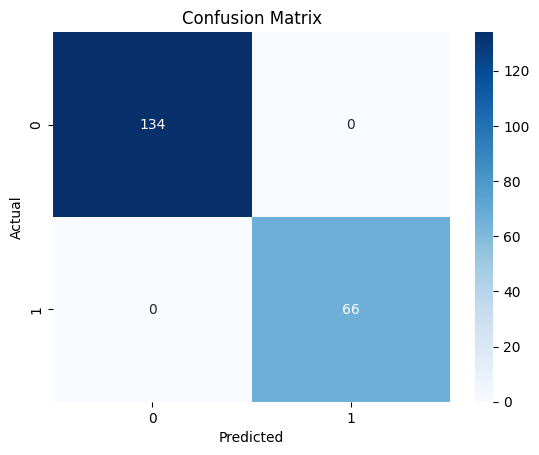

In [6]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()


## Takeaways
- Naive Bayes trained almost instantly compared to iterative models — a big advantage at scale.
- Check `model.theta_` (mean per feature per class) and `model.var_` (variance) to see what the model learned about each class's feature distribution.
- Next steps: try `MultinomialNB` on true word-count/text data (e.g., using `CountVectorizer` on real email text) to see the more classic NLP use case.
---